In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

print(os.getcwd())

c:\Users\Hp\fraud-detection\notebooks


In [2]:
credit = pd.read_csv(
    '../data/raw/creditcard.csv'
)

In [3]:
credit.shape

(50000, 9)

In [4]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           50000 non-null  int64  
 1   Amount         50000 non-null  float64
 2   merchant_risk  50000 non-null  float64
 3   device_risk    50000 non-null  float64
 4   international  50000 non-null  int64  
 5   card_age_days  50000 non-null  int64  
 6   num_items      50000 non-null  int64  
 7   online_order   50000 non-null  int64  
 8   Class          50000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 3.4 MB


In [5]:
credit.describe()

,Time,Amount,merchant_risk,device_risk,international,card_age_days,num_items,online_order,Class
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,86302.457700,54.675480,0.289894,0.312821,0.140940,922.760320,4.005220,0.481500,0.004460
std,49928.278895,76.756677,0.191801,0.229653,0.347963,517.678387,1.999028,0.499663,0.066635
min,0.000000,1.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,0.000000
25%,42972.250000,16.980000,0.143000,0.127000,0.000000,472.000000,2.000000,0.000000,0.000000
50%,86496.000000,33.230000,0.273000,0.293000,0.000000,924.000000,4.000000,0.000000,0.000000
75%,129447.750000,64.885000,0.416000,0.466000,0.000000,1369.000000,6.000000,1.000000,0.000000
max,172796.000000,4943.860000,1.000000,1.000000,1.000000,1824.000000,7.000000,1.000000,1.000000


In [6]:
credit.isnull().sum()

Time             0
Amount           0
merchant_risk    0
device_risk      0
international    0
card_age_days    0
num_items        0
online_order     0
Class            0
dtype: int64

In [7]:
credit.duplicated().sum()

0

In [8]:
credit.drop_duplicates(inplace=True)

In [9]:
credit['Class'].value_counts()

Class
0    49777
1      223
Name: count, dtype: int64

In [10]:
credit['Class'].value_counts(
    normalize=True
)*100

Class
0    99.554
1     0.446
Name: proportion, dtype: float64

<Axes: xlabel='Class', ylabel='count'>

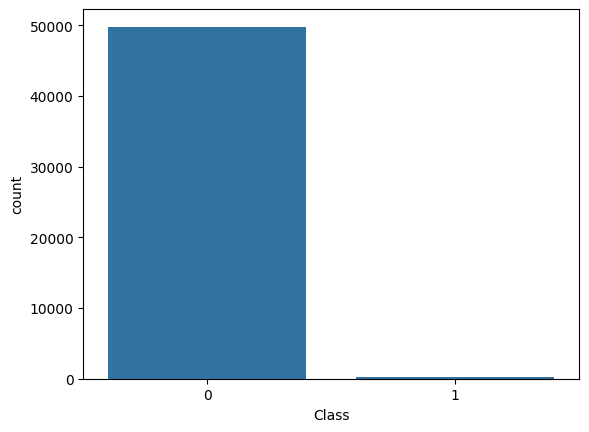

In [11]:
sns.countplot(
    x='Class',
    data=credit
)

<Axes: xlabel='Amount', ylabel='Count'>

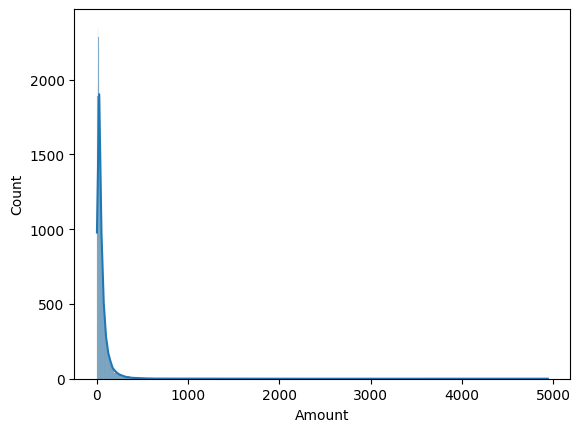

In [12]:
sns.histplot(
    credit['Amount'],
    kde=True
)

<Axes: xlabel='Class', ylabel='Amount'>

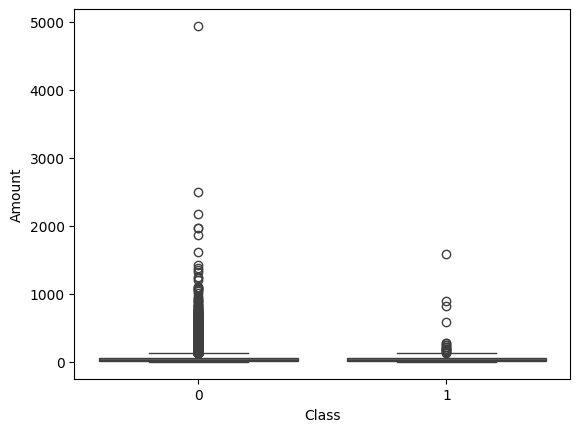

In [13]:
sns.boxplot(
    x='Class',
    y='Amount',
    data=credit
)

<Axes: >

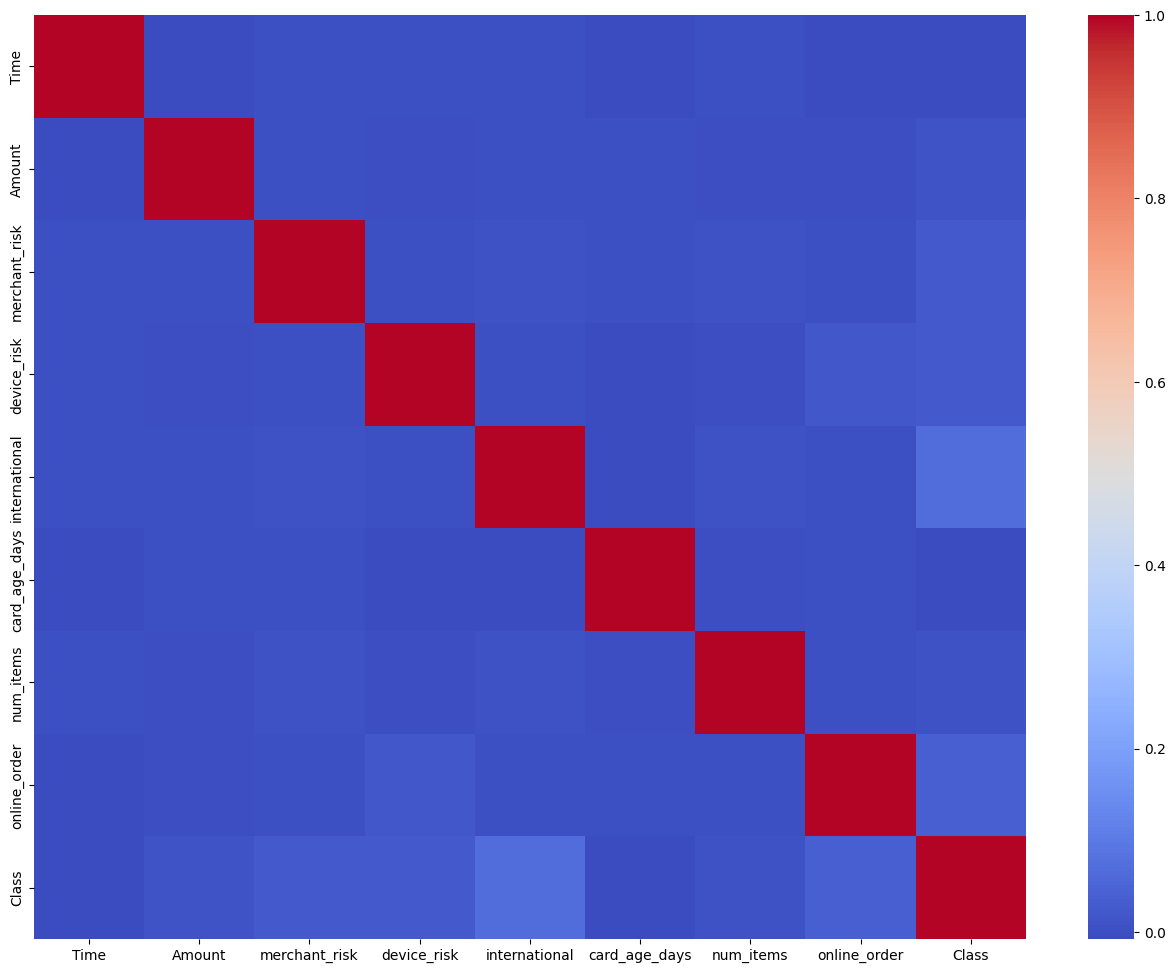

In [14]:
plt.figure(figsize=(16,12))

sns.heatmap(
    credit.corr(),
    cmap='coolwarm'
)

In [15]:
credit.to_csv(
    '../data/processed/credit_clean.csv',
    index=False
)

In [16]:
credit = pd.read_csv(
    '../data/processed/credit_clean.csv'
)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

credit['Amount'] = scaler.fit_transform(
    credit[['Amount']]
)

credit['Time'] = scaler.fit_transform(
    credit[['Time']]
)

In [21]:
credit.to_csv(
    '../data/processed/credit_processed.csv',
    index=False
)